In [1]:
#NumPy is often used for numerical operations
#Pandas is commonly used for data cleaning, analysis, and exploration with tabular data
import numpy as np
import pandas as pd

In [ ]:
## Loading Dataset

In [3]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv") #load the dataset
data_df.head() #show the first 5 rows from the dataset

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
## Checkecing null value
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


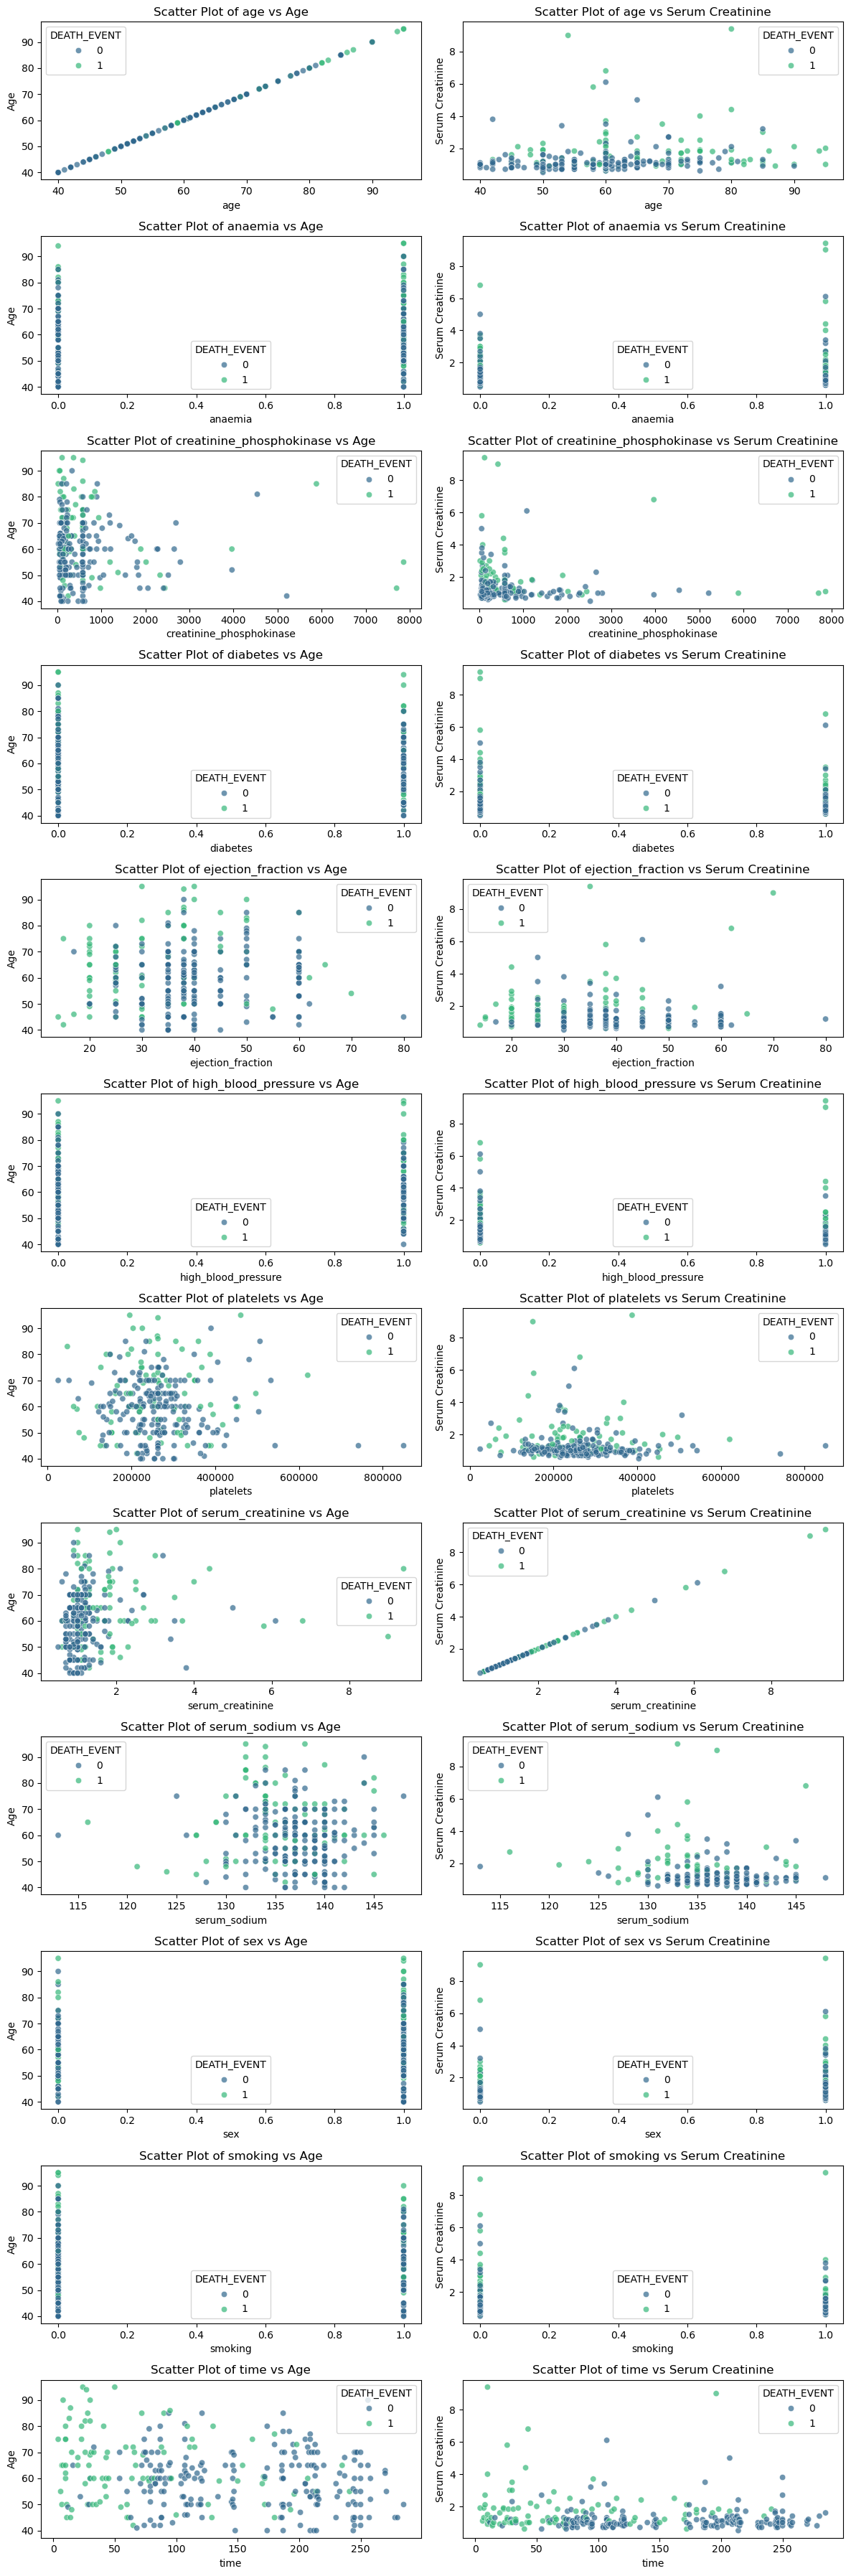

In [19]:
## Visualization of data
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for the scatter plot
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction',
                     'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Set up subplots
fig, axes = plt.subplots(nrows=len(selected_features), ncols=2, figsize=(12, 3 * len(selected_features)))

# Plot scatter plots for each feature
for i, feature in enumerate(selected_features):
    # Scatter plot for feature vs 'age'
    sns.scatterplot(x=feature, y='age', hue='DEATH_EVENT', data=data_df, ax=axes[i, 0], palette='viridis', alpha=0.7)
    axes[i, 0].set_title(f'Scatter Plot of {feature} vs Age')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Age')

    # Scatter plot for feature vs 'serum_creatinine'
    sns.scatterplot(x=feature, y='serum_creatinine', hue='DEATH_EVENT', data=data_df, ax=axes[i, 1], palette='viridis', alpha=0.7)
    axes[i, 1].set_title(f'Scatter Plot of {feature} vs Serum Creatinine')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Serum Creatinine')

# Adjust layout
plt.tight_layout()
plt.show()


In [21]:
## Support vector machine for prediction
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction',
                     'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare the data
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM
model = SVC()
model.fit(X_train_scaled, y_train)

# Evaluate
accuracy = model.score(X_test_scaled, y_test)
print(f"SVM Accuracy: {accuracy:.2f}")

# Classification report
y_pred_test = model.predict(X_test_scaled)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# Random prediction
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_scaled = scaler.transform(random_sample)
y_pred = model.predict(random_scaled)

print("\nRandom Sample for Prediction:")
print(random_sample)
print("Predicted DEATH_EVENT:", y_pred[0])


SVM Accuracy: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        35
           1       0.80      0.48      0.60        25

    accuracy                           0.73        60
   macro avg       0.76      0.70      0.70        60
weighted avg       0.75      0.73      0.72        60


Random Sample for Prediction:
      age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
281  70.0        0                       582         0                 40   

     high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
281                    0    51000.0               2.7           136    1   

     smoking  time  
281        1   250  
Predicted DEATH_EVENT: 0


In [23]:
##  Logistic Regression Model for Predictin
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
data_df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction',
                     'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare features and labels
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)  # Added max_iter to avoid convergence warnings
logistic_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_logistic = logistic_model.predict(X_test)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
conf_matrix = confusion_matrix(y_test, y_pred_logistic)
classification_rep = classification_report(y_test, y_pred_logistic)

# Output
print(f"\n Logistic Regression Accuracy: {accuracy_logistic:.2f}")
print("\n Confusion Matrix:")
print(conf_matrix)
print("\n Classification Report:")
print(classification_rep)

# Predict a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
pred_logistic_sample = logistic_model.predict(random_sample)

print("\n Logistic Regression Predicted DEATH_EVENT:", pred_logistic_sample[0])



 Logistic Regression Accuracy: 0.80

 Confusion Matrix:
[[33  2]
 [10 15]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85        35
           1       0.88      0.60      0.71        25

    accuracy                           0.80        60
   macro avg       0.82      0.77      0.78        60
weighted avg       0.82      0.80      0.79        60


 Logistic Regression Predicted DEATH_EVENT: 0


C:\Users\Varsha Gangasagre\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Decision Tree Accuracy: 0.63

 Confusion Matrix:
[[27  8]
 [14 11]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.77      0.71        35
           1       0.58      0.44      0.50        25

    accuracy                           0.63        60
   macro avg       0.62      0.61      0.61        60
weighted avg       0.63      0.63      0.62        60


 Predicted DEATH_EVENT for random sample: 1


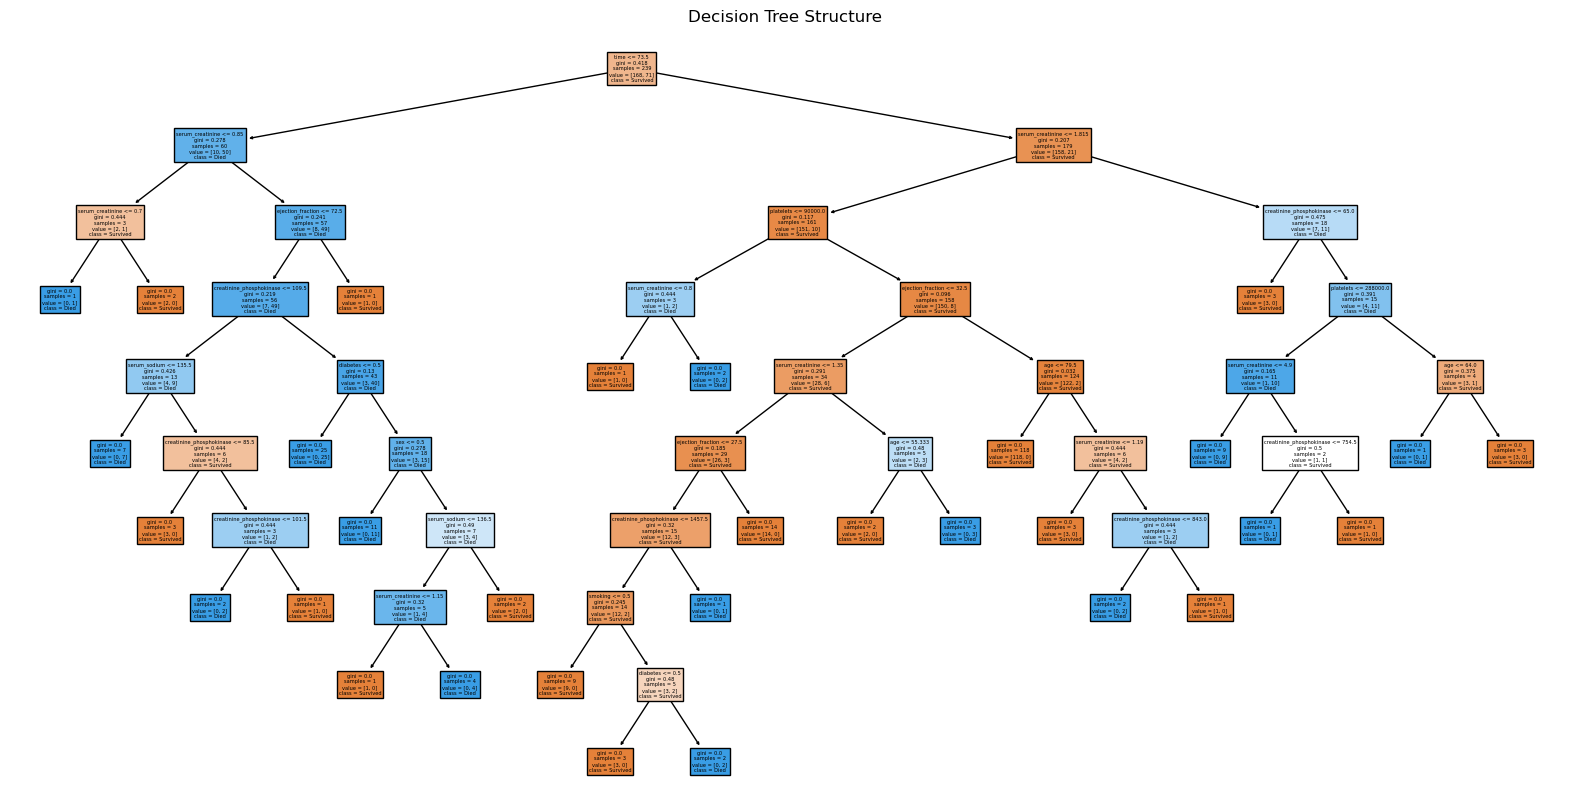

In [29]:
## Decision tree classifier prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                     'ejection_fraction', 'high_blood_pressure', 'platelets',
                     'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare input (X) and output (y)
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on test set
y_pred_test = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred_test)
print(f"\n Decision Tree Accuracy: {accuracy:.2f}")

# Confusion Matrix
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred_test))

# Make prediction on a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_prediction = model.predict(random_sample)
print("\n Predicted DEATH_EVENT for random sample:", random_prediction[0])

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=selected_features, class_names=['Survived', 'Died'], filled=True)
plt.title("Decision Tree Structure")
plt.show()


In [31]:
## Using random forest classifier prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                     'ejection_fraction', 'high_blood_pressure', 'platelets',
                     'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare data
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n Random Forest Accuracy: {accuracy_rf:.2f}")

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Predict on a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_prediction_rf = rf_model.predict(random_sample)
print("\n Random Forest Predicted DEATH_EVENT:", random_prediction_rf[0])



 Random Forest Accuracy: 0.75

 Confusion Matrix:
[[33  2]
 [13 12]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.86      0.48      0.62        25

    accuracy                           0.75        60
   macro avg       0.79      0.71      0.72        60
weighted avg       0.78      0.75      0.73        60


 Random Forest Predicted DEATH_EVENT: 0


In [33]:
##K-Nearest Neighbors (KNN) Classifier for Predictions
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                     'ejection_fraction', 'high_blood_pressure', 'platelets',
                     'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare data
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can try different values for k

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\n KNN Accuracy: {accuracy_knn:.2f}")

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Predict on a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_sample_scaled = scaler.transform(random_sample)
random_prediction_knn = knn_model.predict(random_sample_scaled)
print("\n KNN Predicted DEATH_EVENT:", random_prediction_knn[0])



 KNN Accuracy: 0.68

 Confusion Matrix:
[[34  1]
 [18  7]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.97      0.78        35
           1       0.88      0.28      0.42        25

    accuracy                           0.68        60
   macro avg       0.76      0.63      0.60        60
weighted avg       0.75      0.68      0.63        60


 KNN Predicted DEATH_EVENT: 0


In [37]:
##Gradient Boosting (e.g., XGBoost, LightGBM) prediction
import pandas as pd
!pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                     'ejection_fraction', 'high_blood_pressure', 'platelets',
                     'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare data
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: scale features (XGBoost usually handles scaling well, but helpful for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n XGBoost Accuracy: {accuracy_xgb:.2f}")

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Predict on a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_sample_scaled = scaler.transform(random_sample)
random_prediction_xgb = xgb_model.predict(random_sample_scaled)
print("\n XGBoost Predicted DEATH_EVENT:", random_prediction_xgb[0])


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB 660.6 kB/s eta 0:03:47
   ---------------------------------------- 0.1/150.0 MB 1.3 MB/s eta 0:01:55
   ---------------------------------------- 0.4/150.0 MB 3.0 MB/s eta 0:00:50
   ---------------------------------------- 0.7/150.0 MB 4.1 MB/s eta 0:00:37
   ---------------------------------------- 1.1/150.0 MB 5.2 MB/s eta 0:00:29
   ---------------------------------------- 1.3/150.0 MB 5.0 MB/s eta 0:00:30
   ---------------------------------------- 1.5/150.0 MB 5.3 MB/s eta 0:00:28
   ---------------------------------------- 1.8/150.0 MB 5.7 MB/s eta 0:00:27
    --------------------------------------- 2.1/150.0 MB 5.7 MB/s eta 0:00:27
    --------------------------------------- 2.3/150.0 MB 5.7 MB/s eta 0:00:26
    --------------------------------------- 2.7/150.0 MB 5.9 MB/s eta 0:00:2

C:\Users\Varsha Gangasagre\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:24:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [41]:
## Neural Network (MLPClassifier) for Prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select features
selected_features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                     'ejection_fraction', 'high_blood_pressure', 'platelets',
                     'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

# Prepare features and target
X = data_df[selected_features]
y = data_df['DEATH_EVENT']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (MLP requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train MLPClassifier (Neural Network)
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Evaluation
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\n Neural Network Accuracy: {accuracy_mlp:.2f}")

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_mlp))

# Prediction on a random sample
random_sample = data_df[selected_features].sample(n=1, random_state=42)
random_sample_scaled = scaler.transform(random_sample)
random_prediction_mlp = mlp_model.predict(random_sample_scaled)



 Neural Network Accuracy: 0.72

 Confusion Matrix:
[[30  5]
 [12 13]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        35
           1       0.72      0.52      0.60        25

    accuracy                           0.72        60
   macro avg       0.72      0.69      0.69        60
weighted avg       0.72      0.72      0.71        60



C:\Users\Varsha Gangasagre\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Store results
results = {}

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
results["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, lr_model.predict(X_test_scaled)),
    "prediction": lr_model.predict(random_sample_scaled)[0]
}

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
results["Decision Tree"] = {
    "accuracy": accuracy_score(y_test, dt_model.predict(X_test)),
    "prediction": dt_model.predict(random_sample)[0]
}

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
results["Random Forest"] = {
    "accuracy": accuracy_score(y_test, rf_model.predict(X_test)),
    "prediction": rf_model.predict(random_sample)[0]
}

# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
results["KNN"] = {
    "accuracy": accuracy_score(y_test, knn_model.predict(X_test_scaled)),
    "prediction": knn_model.predict(random_sample_scaled)[0]
}

# SVM
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
results["SVM"] = {
    "accuracy": accuracy_score(y_test, svm_model.predict(X_test_scaled)),
    "prediction": svm_model.predict(random_sample_scaled)[0]
}

# MLP
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(max_iter=500)
mlp_model.fit(X_train_scaled, y_train)
results["MLP (Neural Net)"] = {
    "accuracy": accuracy_score(y_test, mlp_model.predict(X_test_scaled)),
    "prediction": mlp_model.predict(random_sample_scaled)[0]
}

# XGBoost (if installed)
try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train_scaled, y_train)
    results["XGBoost"] = {
        "accuracy": accuracy_score(y_test, xgb_model.predict(X_test_scaled)),
        "prediction": xgb_model.predict(random_sample_scaled)[0]
    }
except ImportError:
    results["XGBoost"] = {
        "accuracy": "XGBoost not installed",
        "prediction": "-"
    }

# Print all results
print("\n📋 Final Results Summary:\n")
for model_name, result in results.items():
    print(f"{model_name}")
    print(f"  Accuracy: {result['accuracy']}")
    print(f"  Predicted DEATH_EVENT (random sample): {result['prediction']}")
    print("-" * 40)
